In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# LOAD DATASET
df = pd.read_csv(r"C:\Users\ALG\Downloads\movies_ds_modified.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
df.info()
df.isnull().sum()

Shape: (4802, 20)

Columns:
 Index(['index', 'budget', 'genres', 'homepage', 'id', 'keywords',
       'original_language', 'original_title', 'popularity', 'release_date',
       'revenue', 'runtime', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'cast', 'director', 'userId'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 4802 entries, 0 to 4801
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              4801 non-null   float64
 1   budget             4796 non-null   float64
 2   genres             4774 non-null   str    
 3   homepage           1707 non-null   str    
 4   id                 4770 non-null   str    
 5   keywords           4390 non-null   str    
 6   original_language  4780 non-null   str    
 7   original_title     4802 non-null   str    
 8   popularity         4801 non-null   float64
 9   release_date       4801 non-null   str    
 10  revenu

index                   1
budget                  6
genres                 28
homepage             3095
id                     32
keywords              412
original_language      22
original_title          0
popularity              1
release_date            1
revenue                 4
runtime                 6
status                  0
tagline               846
title                   0
vote_average           34
vote_count              0
cast                   43
director               30
userId                 44
dtype: int64

In [7]:
# REMOVE DUPLICATES
df.drop_duplicates(inplace=True)

# HANDLE NULL-LIKE VALUES
df.replace(['NaN', 'null', '-', ''], pd.NA, inplace=True)

# MISSING VALUE ANALYSIS
missing_percent = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value %:\n")
print(missing_percent.sort_values(ascending=False))



Missing Value %:

homepage             64.421272
tagline              17.601668
keywords              8.592284
userId                0.917623
cast                  0.896767
vote_average          0.709072
id                    0.667362
director              0.625652
genres                0.583942
original_language     0.458811
runtime               0.125130
budget                0.125130
revenue               0.083420
index                 0.020855
release_date          0.020855
popularity            0.020855
original_title        0.000000
status                0.000000
title                 0.000000
vote_count            0.000000
dtype: float64


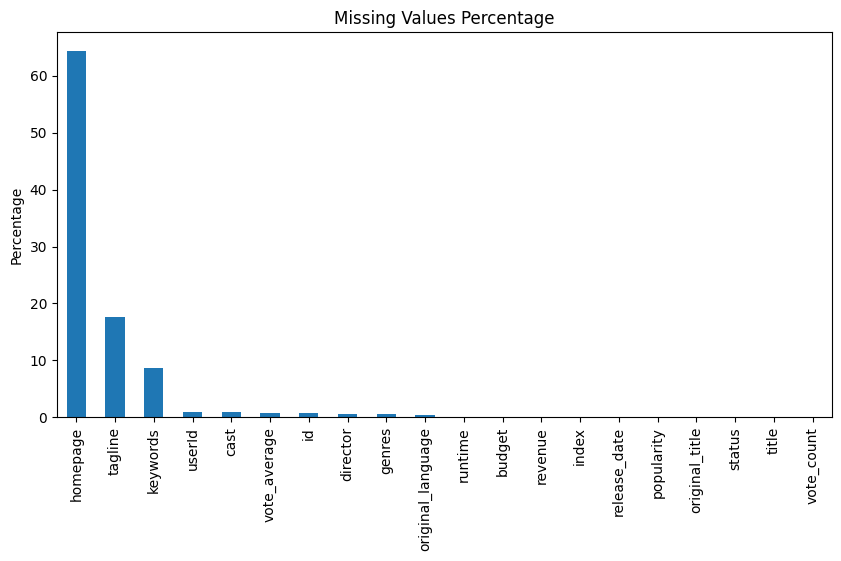

In [8]:
# VISUALIZATION
missing_percent.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Missing Values Percentage")
plt.ylabel("Percentage")
plt.show()

In [9]:
# UNIQUE VALUES (CARDINALITY)
print("\nUnique Values:\n")
for col in df.columns:
    print(col, ":", df[col].nunique())

# LOW VARIANCE CHECK
low_variance = [col for col in df.columns if df[col].nunique() <= 1]
print("\nLow Variance Columns:\n", low_variance)


Unique Values:

index : 4794
budget : 434
genres : 1167
homepage : 1686
id : 4763
keywords : 4211
original_language : 36
original_title : 4793
popularity : 4793
release_date : 3278
revenue : 3285
runtime : 156
status : 3
tagline : 3936
title : 4792
vote_average : 80
vote_count : 1604
cast : 4733
director : 2348
userId : 56

Low Variance Columns:
 []


In [10]:
# CONVERT NUMERIC COLUMNS
num_cols = ['budget', 'revenue', 'runtime', 'popularity', 'vote_average']

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


# HANDLE CATEGORICAL MISSING VALUES (FIXED)
if 'genres' in df.columns:
    df['genres'] = df['genres'].fillna(df['genres'].mode()[0])

if 'original_language' in df.columns:
    df['original_language'] = df['original_language'].fillna(df['original_language'].mode()[0])

if 'userId' in df.columns:
    df['userId'] = df['userId'].fillna('Unknown')

In [11]:
if 'release_date' in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['release_year'] = df['release_date'].dt.year
    df.drop('release_date', axis=1, inplace=True)
    df['release_year'] = df['release_year'].fillna(df['release_year'].median())


Correlation with target:

temp_label      1.000000
vote_average    1.000000
runtime         0.233538
vote_count      0.196257
popularity      0.173229
revenue         0.123234
budget          0.054599
index          -0.058503
release_year   -0.068225
Name: temp_label, dtype: float64


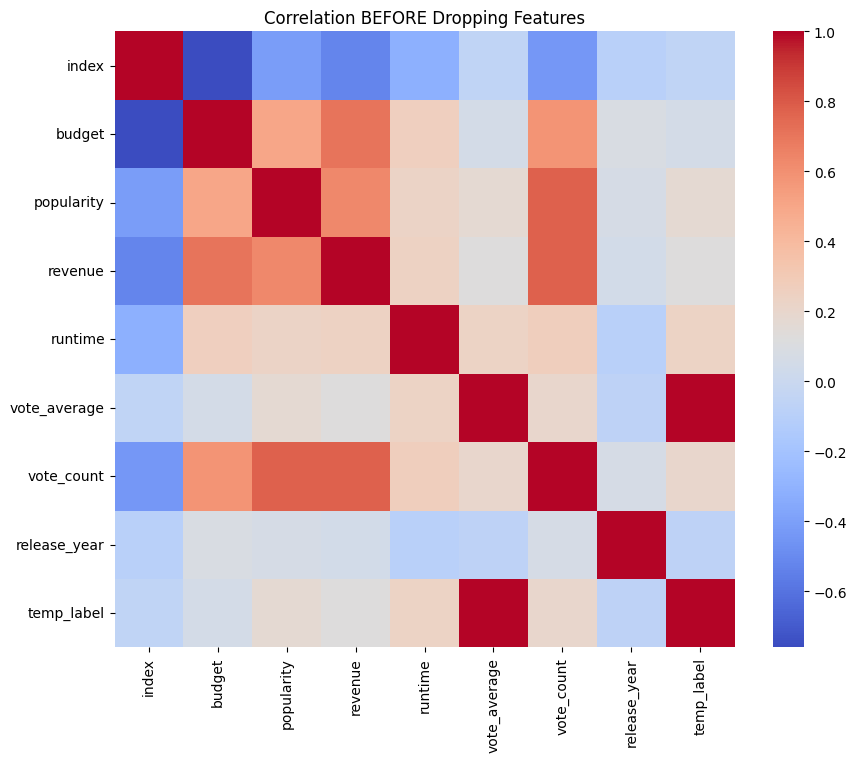

In [12]:
# TEMP TARGET FOR ANALYSIS
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')
df['temp_label'] = df['vote_average']

# CORRELATION ANALYSIS (BEFORE DROPPING)
corr = df.corr(numeric_only=True)

print("\nCorrelation with target:\n")
print(corr['temp_label'].sort_values(ascending=False))

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation BEFORE Dropping Features")
plt.show()

In [13]:
# Identify low correlation features
low_corr = corr['temp_label'][abs(corr['temp_label']) < 0.1].index
print("\nLow Correlation Features:\n", low_corr)


Low Correlation Features:
 Index(['index', 'budget', 'release_year'], dtype='str')


In [14]:
df.drop(['index', 'budget'], axis=1, inplace=True)

In [17]:
# DROP BASED ON ANALYSIS

# Drop columns with >50% missing values
cols_to_drop = missing_percent[missing_percent > 50].index
print("\nDropping columns (missing >50%):", cols_to_drop)
df.drop(cols_to_drop, axis=1, inplace=True)

important_cols = ['userId', 'genres', 'popularity', 'vote_count', 'revenue']

cols_to_drop_cardinality = []

for col in high_cardinality:
    if col not in important_cols:
        cols_to_drop_cardinality.append(col)

df.drop(cols_to_drop_cardinality, axis=1, inplace=True)

# Drop low variance columns
low_variance = [col for col in df.columns if df[col].nunique() <= 1]
print("\nDropping low variance columns:", low_variance)
df.drop(low_variance, axis=1, inplace=True)



Dropping columns (missing >50%): Index(['homepage'], dtype='str')


KeyError: "['homepage'] not found in axis"

In [18]:
# FINAL CLEANUP
df.drop('temp_label', axis=1, inplace=True)

print("\nFinal Missing Values:\n")
print(df.isnull().sum())

print("\nFinal Shape:", df.shape)

# SAVE CLEAN DATASET
df.to_csv("preprocessed_data.csv", index=False, encoding="utf-8")

print("\n Preprocessing Completed & File Saved")


Final Missing Values:

genres                 0
id                    32
keywords             412
original_language      0
original_title         0
popularity             0
revenue                0
runtime                0
status                 0
tagline              844
title                  0
vote_average           0
vote_count             0
cast                  43
director              30
userId                 0
release_year           0
dtype: int64

Final Shape: (4795, 17)

 Preprocessing Completed & File Saved



Missing Value %:

tagline              17.601668
keywords              8.592284
cast                  0.896767
id                    0.667362
director              0.625652
genres                0.000000
popularity            0.000000
original_language     0.000000
original_title        0.000000
status                0.000000
runtime               0.000000
revenue               0.000000
title                 0.000000
vote_count            0.000000
vote_average          0.000000
userId                0.000000
release_year          0.000000
dtype: float64


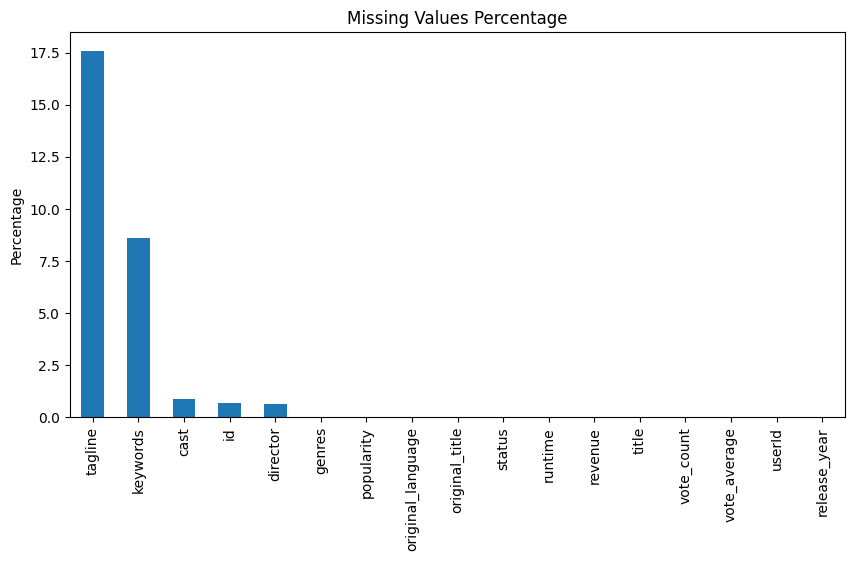

In [19]:
# MISSING VALUE ANALYSIS
missing_percent = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value %:\n")
print(missing_percent.sort_values(ascending=False))

# VISUALIZATION
missing_percent.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Missing Values Percentage")
plt.ylabel("Percentage")
plt.show()


In [22]:
df.isnull().sum()

genres                 0
id                    32
keywords             412
original_language      0
original_title         0
popularity             0
revenue                0
runtime                0
status                 0
tagline              844
title                  0
vote_average           0
vote_count             0
cast                  43
director              30
userId                 0
release_year           0
dtype: int64

In [25]:
df= df.drop(["keywords", "tagline","cast","director"], axis=1)


In [26]:
df=df.drop("id" ,axis=1)


In [29]:
print(df.isnull().sum())
print("\nColumns:\n", df.columns)

genres               0
original_language    0
original_title       0
popularity           0
revenue              0
runtime              0
status               0
title                0
vote_average         0
vote_count           0
userId               0
release_year         0
dtype: int64

Columns:
 Index(['genres', 'original_language', 'original_title', 'popularity',
       'revenue', 'runtime', 'status', 'title', 'vote_average', 'vote_count',
       'userId', 'release_year'],
      dtype='str')


In [30]:
df.to_csv("prep.csv", index=False, encoding="utf-8")

In [31]:
import pandas as pd
dt=pd.read_csv("prep.csv")
dt.head()

,genres,original_language,original_title,popularity,revenue,runtime,status,title,vote_average,vote_count,userId,release_year
0,Action Adventure Fantasy Science Fiction,en,Avatar,150.437577,2.787965e+09,103.0,Released,Avatar,7.2,11800,45,2009.0
1,Adventure Fantasy Action,en,Pirates of the Caribbean: At World's End,139.082615,9.610000e+08,169.0,Released,Pirates of the Caribbean: At World's End,6.9,4500,43,2006.0
2,Action Adventure Crime,en,Spectre,107.376788,8.806746e+08,148.0,Released,Spectre,6.3,4466,37,2006.0
3,Action Crime Drama Thriller,en,The Dark Knight Rises,112.312950,1.084939e+09,165.0,Released,The Dark Knight Rises,7.6,9106,4,2006.0
4,Action Adventure Science Fiction,en,John Carter,43.926995,2.841391e+08,132.0,Released,John Carter,6.1,2124,40,2012.0


In [32]:
dt.isnull().sum()


genres               0
original_language    0
original_title       0
popularity           0
revenue              0
runtime              0
status               0
title                0
vote_average         0
vote_count           0
userId               0
release_year         0
dtype: int64